# A notebook for testing, saving, and every kind of random stuff

In [1]:
import numpy as np
from dataset.data_generator import *
from utils.other_utils import *
import matplotlib.pyplot as plt
import os

## cue data generator

In [23]:
number_of_data_samples = 500
data_duration = 30
cue_first_time = 10
cue_last_time = 20
sine_length = 5
sine_amplitude = 1
dt = 0.01

In [19]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, cue_idx, sine_last_idx = cue_signal_generator(data_duration,
                                                                  cue_first_time,
                                                                  cue_last_time,
                                                                  sine_length,
                                                                  sine_amplitude,
                                                                  dt)
    data = {'data_x': data_x,
            'data_y': data_y,
            'cue_idx': cue_idx,
            'sine_last_idx': sine_last_idx,
            'dt': dt}

    all_data.append(data)

In [20]:
path_to_save = '/home/matin/McMaster/trimba/phd_codes/ctrnn/pytorch/generated_datasets'
# data_name = 'cue_f5_l12_sl5_sa1_dt01'
data_name = 'samples_500_duration_30_dt01_cue_f10_l20_sl5_sa1'
save(path_to_save, data_name, all_data)

1

## test data loader

In [2]:
from torch.utils.data import SubsetRandomSampler
import torch.utils.data
from dataset.cue_data import *

In [3]:
class config:
    class dataset:
        path_to_data = '/home/matin/McMaster/trimba/phd_codes/ctrnn/pytorch/generated_datasets/cue_f5_l12_sl5_sa1_dt01.pkl'
        input_transform = None
        target_transform = None
    pass

In [4]:
conf = config
data_set = CueData(conf)

In [5]:
train_loader = torch.utils.data.DataLoader(
    data_set,
    batch_size=10,
    num_workers=0)

In [6]:
data_x, data_y, cue_idx, sine_last_idx = next(iter(train_loader))

In [17]:
len(data_x)

10

In [18]:
cue_idx

tensor([ 640, 1022,  739,  985, 1195, 1198, 1131,  919,  520,  652])

## test cue trained model

### data

In [46]:
number_of_data_samples = 1
data_duration = 30
cue_first_time = 10
cue_last_time = 20
sine_length = 5
sine_amplitude = 1
dt = 0.01

In [47]:
data_x, data_y, cue_idx, sine_last_idx = cue_signal_generator(data_duration,
                                                              cue_first_time,
                                                              cue_last_time,
                                                              sine_length,
                                                              sine_amplitude,
                                                              dt)

### model

In [140]:
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

In [141]:
config_file_path = '/home/matin/McMaster/trimba/phd_codes/ctrnn/pytorch/experiments/CTRNN/CTRNN_cue_data_2023-Jan-04-00-03-10_1139702/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))

In [142]:
model = CTRNN(config.model)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
load_model(model, model_file, config.device)

In [143]:
activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

Text(0.5, 1.0, 'data_y')

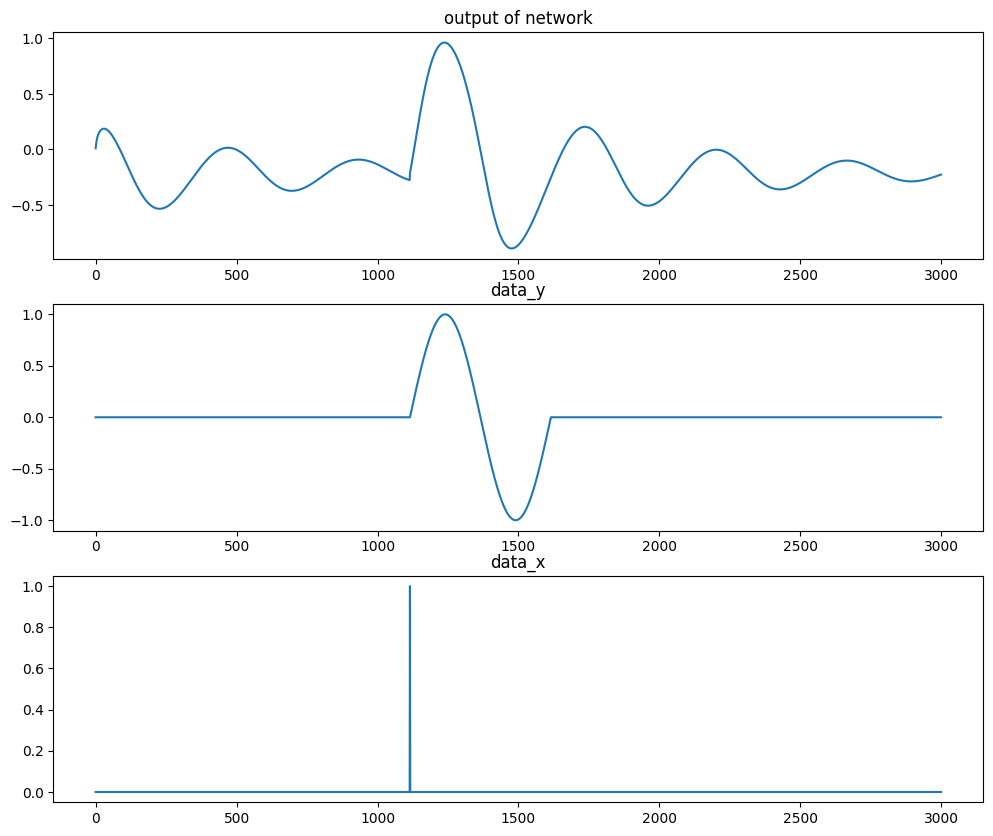

In [144]:
x_range = np.arange(3000)
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range, outputs.detach().view(3000))
axs[0].set_title('output of network')
axs[2].plot(x_range, data_x.view(3000))
axs[2].set_title('data_x')
axs[1].plot(x_range, data_y.view(3000))
axs[1].set_title('data_y')

## ready_set_go data generator

In [13]:
number_of_data_samples = 1000
data_duration = 40
first_cue_first_time = 10
first_cue_last_time = 20
min_interval = 2
max_interval = 8
sine_amplitude = 1
cue_amplitude = 0.3
dt = 0.01

In [14]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, first_cue_idx, second_cue_idx, sine_last_idx = ready_set_go_generator(data_duration,
                                                                                          first_cue_first_time,
                                                                                          first_cue_last_time,
                                                                                          min_interval,
                                                                                          max_interval,
                                                                                          sine_amplitude,
                                                                                          cue_amplitude,
                                                                                          dt)
    data = {'data_x': data_x,
            'data_y': data_y,
            'first_cue_idx': first_cue_idx,
            'second_cue_idx': second_cue_idx,
            'sine_last_idx': sine_last_idx,
            'dt': dt}

    all_data.append(data)

In [15]:
path_to_save = '/home/matin/trimba/phd_codes/ctrnn_pytorch/generated_datasets'
data_name = 'ready_set_go_samples_1000_duration_40_dt01_cue_f10_l20_interval_2_8_sa1_cuea3e-1'
save(path_to_save, data_name, all_data)

1

## test ready_set_go trained model

Text(0.5, 1.0, 'data_y')

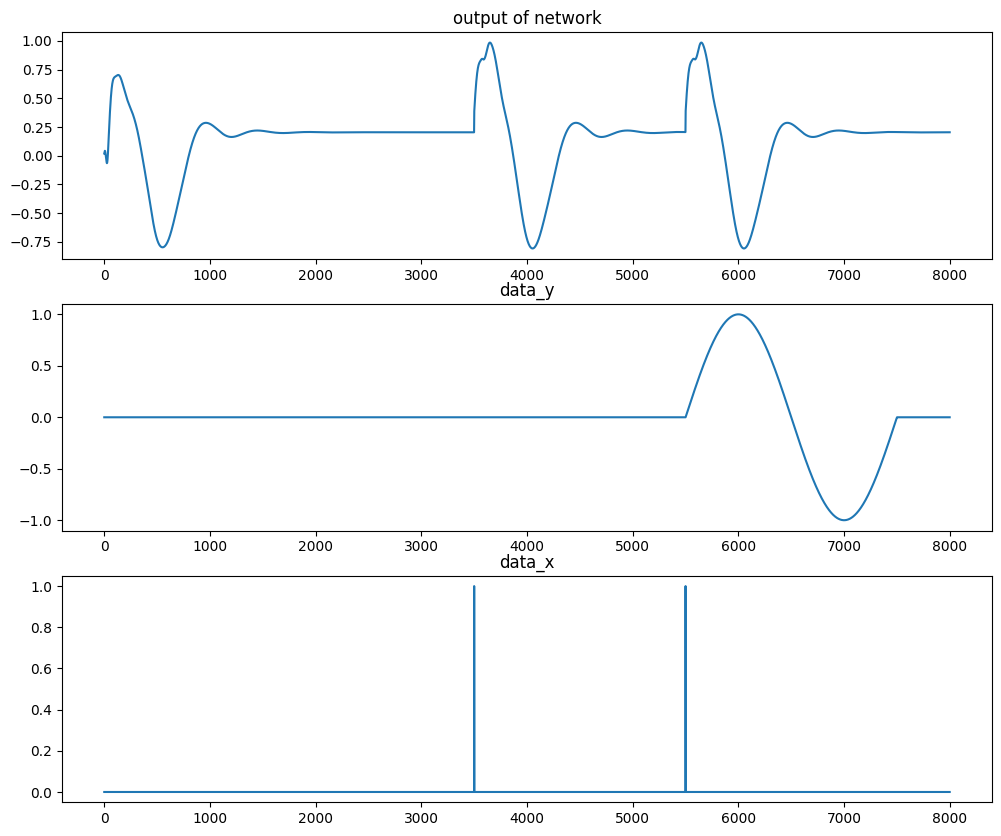

In [52]:
# data
data_duration = 80
first_cue_time = 35
second_cue_time = 55
sine_amplitude = 1
dt = 0.01
data_x, data_y, first_cue_idx, second_cue_idx, sine_last_idx = ready_set_go_forced_generator(data_duration,
                                                                                             first_cue_time,
                                                                                             second_cue_time,
                                                                                             sine_amplitude,
                                                                                             dt)


# model
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

config_file_path = '/home/matin/trimba/phd_codes/ctrnn_pytorch/experiments/CTRNN/ready_set_go/CTRNN_ready_set_go_data_2023-Jan-11-15-39-16_544738/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
load_model(model, model_file, config.device)
model.to('cpu')

activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

len_data_points = int(data_duration * (1 / dt))
# plots
x_range = np.arange(len_data_points)
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range, outputs.detach().view(len_data_points))
axs[0].set_title('output of network')
axs[2].plot(x_range, data_x.view(len_data_points))
axs[2].set_title('data_x')
axs[1].plot(x_range, data_y.view(len_data_points))
axs[1].set_title('data_y')

# Testing gaussian loss function

In [25]:
dt = 0.001
x = torch.arange(10000).reshape((1, 10000)) * dt
y = scaled_gaussian_derivative_shape(x, 2, 0.4, 0.99)

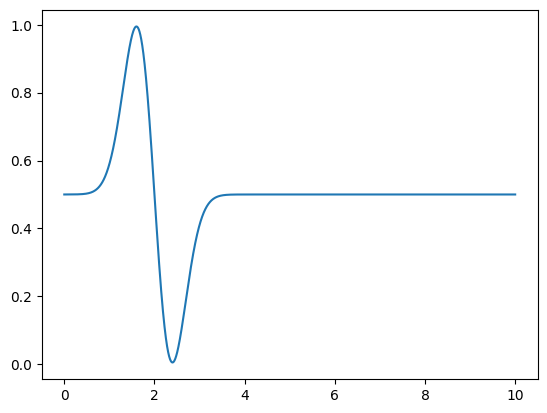

In [26]:
plt.plot(torch.flatten(x), torch.flatten(y))

# Gaussian loss function data generator


In [16]:
number_of_data_samples = 1000
data_duration = 40
first_cue_first_time = 10
first_cue_last_time = 20
min_interval = 2
max_interval = 8
variance = 0.4
scale = 0.99
cue_amplitude = 1
dt = 0.01

In [17]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, first_cue_idx, second_cue_idx, concavity = gaussian_derivative_loss_data(data_duration,
                                                                                             first_cue_first_time,
                                                                                             first_cue_last_time,
                                                                                             min_interval,
                                                                                             max_interval,
                                                                                             cue_amplitude,
                                                                                             variance,
                                                                                             scale,
                                                                                             dt)

    data = {'data_x': data_x,
            'data_y': data_y,
            'first_cue_idx': first_cue_idx,
            'second_cue_idx': second_cue_idx,
            'concavity_change': concavity,
            'variance': variance,
            'scale': scale,
            'dt': dt}

    all_data.append(data)

In [18]:
path_to_save = '/home/matin/McMaster/trimba/phd_codes/CTRNN/generated_datasets'
data_name = 'gaussian_loss_shape_samples_1000_duration_40_dt01_cue_f10_l20_interval_2_8_sa1_cuea1_variance0.4_scale0.99'
save(path_to_save, data_name, all_data)

1

# testing gaussian loss function

In [55]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def loss_test(x, y):
    return y*sigmoid(x) + (1-y)*(1-sigmoid(x))

In [56]:
dt = 0.001
# x = torch.arange(10000).reshape((1, 10000)) * dt
x = torch.arange(10000)*dt
y1 = scaled_gaussian_derivative_shape(x, 2, 0.4, 0.99)
y2 = scaled_gaussian_derivative_shape(x, 5, 0.6, 0.99)

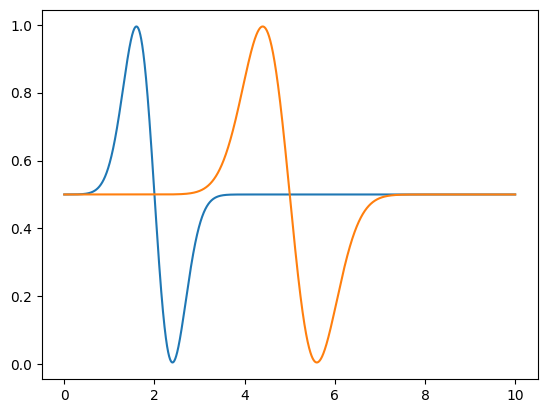

In [57]:
plt.plot(torch.flatten(x), torch.flatten(y1))
plt.plot(torch.flatten(x), torch.flatten(y2))

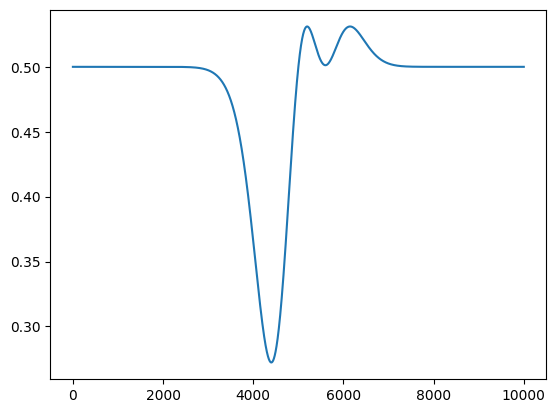

In [59]:
loss = loss_test(-y2, y2)
plt.plot(loss)

4350

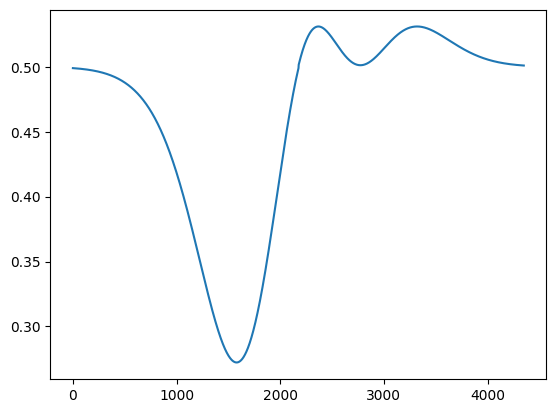

In [73]:
plt.plot(loss[torch.abs(loss - 0.50) > 0.001])

torch.sum(loss[torch.abs(loss - 0.50) > 0.001])
len(loss[torch.abs(loss - 0.50) > 0.001])